In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


c:\Users\USER\miniconda3\envs\fist_env\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Check shapes
print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (60000, 28, 28) (60000,)
Test data shape: (10000, 28, 28) (10000,)


In [ ]:
# Normalize the images 
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels for encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


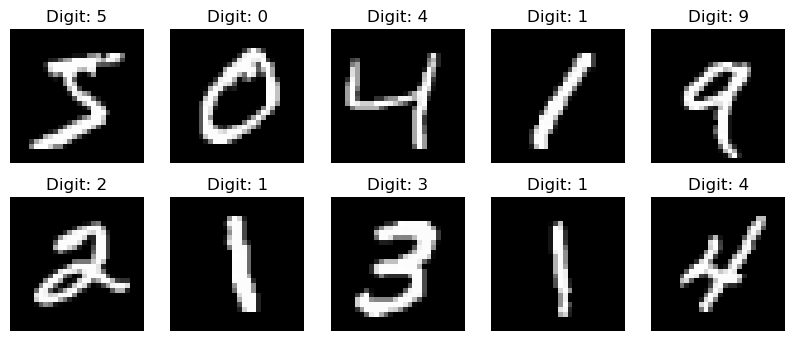

In [ ]:
# Plot some sample images, sample ko plot kia ha
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Digit: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.show()



In [ ]:
# Simple feedforward neural network  ,pic 28*28 ke han tu simple ANN model use kia ha
model = Sequential([
    Flatten(input_shape=(28,28)),  # Flatten 28x28 images to 784 vector
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 output classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model.summary()


c:\Users\USER\miniconda3\envs\fist_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9225 - loss: 0.2650 - val_accuracy: 0.9622 - val_loss: 0.1318
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9672 - loss: 0.1133 - val_accuracy: 0.9650 - val_loss: 0.1170
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9763 - loss: 0.0777 - val_accuracy: 0.9682 - val_loss: 0.1070
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9814 - loss: 0.0593 - val_accuracy: 0.9712 - val_loss: 0.0962
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9852 - loss: 0.0447 - val_accuracy: 0.9674 - val_loss: 0.1243
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9880 - loss: 0.0380 - val_accuracy: 0.9715 - val_loss: 0.1087
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9906 - loss: 0.0288 - val_accuracy: 0.9703 - val_loss: 0.1187
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9912 - loss: 0.0275 

In [ ]:
# Evaluate on test set   ,accuracy check karnay k lie ,model overfit ya underfit tu nhi ha check karnay k lie
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9754 - loss: 0.0958
Test Accuracy: 0.9753999710083008


In [ ]:
# Predict first 10 images , actuall vs predicted check karnay k lie 
predictions = model.predict(X_test[:10])

for i, pred in enumerate(predictions):
    print(f"Predicted: {np.argmax(pred)}, True: {np.argmax(y_test[i])}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Predicted: 7, True: 7
Predicted: 2, True: 2
Predicted: 1, True: 1
Predicted: 0, True: 0
Predicted: 4, True: 4
Predicted: 1, True: 1
Predicted: 4, True: 4
Predicted: 9, True: 9
Predicted: 5, True: 5
Predicted: 9, True: 9


In [ ]:
# model save kar dia ha 

In [10]:
from tensorflow.keras.models import load_model

model = load_model("mnist_model.h5")
